#BÀI 4: NHẬP VÀ XUẤT DỮ LIỆU

In [ ]:
#BÀI 4: NHẬP VÀ XUẤT DỮ LIỆU

In [ ]:
# Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# Đường dẫn thư mục chứa dữ liệu pizza_sales trên Drive
DATA_PATH = '/content/drive/MyDrive/pizza_sales/'

# 1.Đọc 4 file CSV vào DataFrame
orders        = pd.read_csv(DATA_PATH + 'orders.csv')
order_details = pd.read_csv(DATA_PATH + 'order_details.csv')
pizzas        = pd.read_csv(DATA_PATH + 'pizzas.csv')
pizza_types = pd.read_csv(DATA_PATH + 'pizza_types.csv', encoding='latin-1')

print("Đọc dữ liệu thành công!")

Đọc dữ liệu thành công!


In [ ]:
#  2. Khám phá cấu trúc từng bảng
# Bảng `orders` — Thông tin đơn hàng

print("Shape:", orders.shape)
print("Columns:", orders.columns.tolist())
print()
orders.info()
orders.head(3)

# Bảng `order_details` — Chi tiết từng dòng đơn

print("Shape:", order_details.shape)
print("Columns:", order_details.columns.tolist())
print()
order_details.info()
order_details.head(3)

# Bảng `pizzas` — Danh mục pizza & giá

print("Shape:", pizzas.shape)
print("columns:", pizzas.columns.tolist())
print()
pizzas.info()
pizzas.head(3)

# Bảng `pizza_types` — Loại pizza & nguyên liệu

print("Shape:", pizza_types.shape)
print("Columns:", pizza_types.columns.tolist())
print()
pizza_types.info()
pizza_types.head(3)


Shape: (21350, 3)
Columns: ['order_id', 'date', 'time']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB
Shape: (48620, 4)
Columns: ['order_details_id', 'order_id', 'pizza_id', 'quantity']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
Shape: (96, 4)
columns: ['pizza_id', 'pizza_type_id', 'size', 'price']

<c

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."


In [ ]:
# 3. Xử lý & hợp nhất dữ liệu (merge)

# Bước 1: Gắn thông tin pizza vào chi tiết đơn hàng
df = order_details.merge(pizzas, on='pizza_id', how='left')

# Bước 2: Gắn tên & loại pizza
df = df.merge(pizza_types, on='pizza_type_id', how='left')

# Bước 3: Gắn ngày & giờ đặt hàng
df = df.merge(orders, on='order_id', how='left')

# Bước 4: Tính doanh thu từng dòng
df['revenue'] = df['quantity'] * df['price']

# Bước 5: Chuyển kiểu dữ liệu date & time
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

print("Merge hoàn tất!")
print("Shape sau merge:", df.shape)
df.head(3)

Merge hoàn tất!
Shape sau merge: (48620, 13)


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time,revenue
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36,13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40,16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40,18.50


In [ ]:
# 4. Lưu dữ liệu đã xử lý ra file mới

OUTPUT_PATH = '/content/drive/MyDrive/pizza_sales/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Lưu toàn bộ bảng tổng hợp
df.to_csv(OUTPUT_PATH + 'pizza_sales_processed.csv', index=False, encoding='utf-8-sig')

print("Đã lưu: pizza_sales_processed.csv")
print(f"   → {OUTPUT_PATH}pizza_sales_processed.csv")

Đã lưu: pizza_sales_processed.csv
   → /content/drive/MyDrive/pizza_sales/pizza_sales_processed.csv


In [ ]:
# Đảm bảo pizza_types đọc đúng encoding trước
pizza_types = pd.read_csv(DATA_PATH + 'pizza_types.csv', encoding='latin-1')

# Merge lần lượt
df = order_details.merge(pizzas, on='pizza_id', how='left')
df = df.merge(pizza_types, on='pizza_type_id', how='left')
df = df.merge(orders, on='order_id', how='left')

# Tạo cột revenue sau khi đã có cột price
df['revenue'] = df['quantity'] * df['price']

print(df.columns.tolist())

['order_details_id', 'order_id', 'pizza_id', 'quantity', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'date', 'time', 'revenue']


In [ ]:
# 5. INSIGHT BÀI 4

mem_usage = df.memory_usage(deep=True).sum()

print("=" * 55)
print("       INSIGHT BÀI 4 — NHẬP & XUẤT DỮ LIỆU")
print("=" * 55)

print("\n NGUỒN DỮ LIỆU (4 bảng CSV từ Google Drive)")
summary = {
    'orders':        orders,
    'order_details': order_details,
    'pizzas':        pizzas,
    'pizza_types':   pizza_types,
}
for name, tbl in summary.items():
    mem = tbl.memory_usage(deep=True).sum()
    print(f"  • {name:<16} → {tbl.shape[0]:>6,} hàng × {tbl.shape[1]} cột "
          f"| Bộ nhớ: {mem/1024:.1f} KB")

print("\n BẢNG TỔNG HỢP SAU XỬ LÝ (pizza_sales_processed)")
print(f"  • Số hàng   : {df.shape[0]:,}")
print(f"  • Số cột    : {df.shape[1]}")
print(f"  • Cột gồm   : {', '.join(df.columns.tolist())}")
print(f"  • Bộ nhớ    : {mem_usage/1024:.1f} KB")
print(f"  • Doanh thu : ${df['revenue'].sum():,.2f}")

print("\n NHẬN XÉT")
print("  ✔ Đọc thành công 4 file CSV bằng pd.read_csv() qua Google Drive.")
print("  ✔ Khám phá cấu trúc: shape, columns, info() cho từng bảng.")
print("  ✔ Merge 4 bảng theo khoá ngoại (pizza_id, pizza_type_id, order_id).")
print("  ✔ Tạo cột revenue = quantity × price để phục vụ phân tích tiếp theo.")
print("  ✔ Lưu kết quả ra file CSV mới với encoding utf-8-sig (hỗ trợ Excel).")
print("=" * 55)

       INSIGHT BÀI 4 — NHẬP & XUẤT DỮ LIỆU

 NGUỒN DỮ LIỆU (4 bảng CSV từ Google Drive)
  • orders           → 21,350 hàng × 3 cột | Bộ nhớ: 2585.5 KB
  • order_details    → 48,620 hàng × 4 cột | Bộ nhớ: 4019.3 KB
  • pizzas           →     96 hàng × 4 cột | Bộ nhớ: 16.8 KB
  • pizza_types      →     32 hàng × 4 cột | Bộ nhớ: 9.7 KB

 BẢNG TỔNG HỢP SAU XỬ LÝ (pizza_sales_processed)
  • Số hàng   : 48,620
  • Số cột    : 13
  • Cột gồm   : order_details_id, order_id, pizza_id, quantity, pizza_type_id, size, price, name, category, ingredients, date, time, revenue
  • Bộ nhớ    : 27105.9 KB
  • Doanh thu : $817,860.05

 NHẬN XÉT
  ✔ Đọc thành công 4 file CSV bằng pd.read_csv() qua Google Drive.
  ✔ Khám phá cấu trúc: shape, columns, info() cho từng bảng.
  ✔ Merge 4 bảng theo khoá ngoại (pizza_id, pizza_type_id, order_id).
  ✔ Tạo cột revenue = quantity × price để phục vụ phân tích tiếp theo.
  ✔ Lưu kết quả ra file CSV mới với encoding utf-8-sig (hỗ trợ Excel).


# Bài 5: LÀM SẠCH VÀ CHUẨN BỊ DỮ LIỆU

In [ ]:
# Bài 5: LÀM SẠCH VÀ CHUẨN BỊ DỮ LIỆU

In [ ]:
#1. PHÁT HIỆN VÀ XỬ LÝ DỮ LIỆU THIẾU (Missing Values)

# Tổng hợp missing values của tất cả bảng
print("=" * 55)
print(f"{'Bảng':<15} {'Cột':<20} {'Missing':>7} {'%':>7}")
print("=" * 55)

for name, df in [("orders", orders), ("order_details", order_details),
                 ("pizza_types", pizza_types), ("pizzas", pizzas)]:
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        pct    = n_miss / len(df) * 100
        flag   = " " if n_miss > 0 else ""
        print(f"{name:<15} {col:<20} {n_miss:>7,} {pct:>6.1f}%{flag}")
    print("-" * 55)

Bảng            Cột                  Missing       %
orders          order_id                   0    0.0%
orders          date                       0    0.0%
orders          time                       0    0.0%
-------------------------------------------------------
order_details   order_details_id           0    0.0%
order_details   order_id                   0    0.0%
order_details   pizza_id                   0    0.0%
order_details   quantity                   0    0.0%
-------------------------------------------------------
pizza_types     pizza_type_id              0    0.0%
pizza_types     name                       0    0.0%
pizza_types     category                   0    0.0%
pizza_types     ingredients                0    0.0%
-------------------------------------------------------
pizzas          pizza_id                   0    0.0%
pizzas          pizza_type_id              0    0.0%
pizzas          size                       0    0.0%
pizzas          price                

In [ ]:
# 2. XỬ LÝ CHUỖI KÝ TỰ (String Processing)

# strip() — Loại bỏ khoảng trắng thừa

# Giả lập dữ liệu có khoảng trắng thừa
pizza_types_demo = pizza_types.copy()
pizza_types_demo.loc[0, "name"]     = "  The Barbecue Chicken Pizza  "
pizza_types_demo.loc[1, "category"] = " Chicken "

print("Trước khi strip:")
print(pizza_types_demo[["name", "category"]].head(3))

# Áp dụng strip cho toàn bộ cột chuỗi
for col in ["name", "category", "ingredients"]:
    pizza_types_demo[col] = pizza_types_demo[col].str.strip()

print("\nSau khi strip:")
print(pizza_types_demo[["name", "category"]].head(3))

# lower() / upper() — Chuẩn hoá chữ hoa/thường

# Giả lập category có chữ hoa/thường không nhất quán
pizza_types_demo2 = pizza_types.copy()
pizza_types_demo2.loc[0, "category"] = "CHICKEN"
pizza_types_demo2.loc[1, "category"] = "classic"
pizza_types_demo2.loc[2, "category"] = "Supreme"

print("Trước khi chuẩn hoá:")
print(pizza_types_demo2["category"].head(5).tolist())

# Chuẩn hoá: viết hoa chữ cái đầu (title case)
pizza_types_demo2["category"] = pizza_types_demo2["category"].str.strip().str.title()

print("Sau khi .str.title():")
print(pizza_types_demo2["category"].head(5).tolist())
print("Unique:", pizza_types_demo2["category"].unique().tolist())

# replace() — Thay thế ký tự / chuỗi

# Ví dụ 1: Rút ngắn tên size (dùng bảng pizzas)
pizzas_demo2 = pizzas.copy()
size_map = {"S": "Small", "M": "Medium", "L": "Large", "XL": "X-Large", "XXL": "XX-Large"}
pizzas_demo2["size_full"] = pizzas_demo2["size"].replace(size_map)
print("Mở rộng tên size:")
print(pizzas_demo2[["pizza_id", "size", "size_full"]].head(6))

# Ví dụ 2: Xoá tiền tố "The " khỏi tên pizza
pizza_types_clean = pizza_types.copy()
pizza_types_clean["name_short"] = pizza_types_clean["name"].str.replace(r"^The\s+", "", regex=True)
print("\nTên pizza (bỏ tiền tố 'The '):")
print(pizza_types_clean[["name", "name_short"]].head(4))

# unique() — Kiểm tra các giá trị duy nhất

print("Giá trị duy nhất - category:", pizza_types["category"].unique().tolist())
print("Số lượng category:", pizza_types["category"].nunique())
print()
print("Giá trị duy nhất - size:", pizzas["size"].unique().tolist())
print("Số lượng size:", pizzas["size"].nunique())
print()
print("Phân phối theo category:")
print(pizza_types["category"].value_counts())


Trước khi strip:
                             name   category
0    The Barbecue Chicken Pizza      Chicken
1    The California Chicken Pizza   Chicken 
2       The Chicken Alfredo Pizza    Chicken

Sau khi strip:
                           name category
0    The Barbecue Chicken Pizza  Chicken
1  The California Chicken Pizza  Chicken
2     The Chicken Alfredo Pizza  Chicken
Trước khi chuẩn hoá:
['CHICKEN', 'classic', 'Supreme', 'Chicken', 'Chicken']
Sau khi .str.title():
['Chicken', 'Classic', 'Supreme', 'Chicken', 'Chicken']
Unique: ['Chicken', 'Classic', 'Supreme', 'Veggie']
Mở rộng tên size:
     pizza_id size size_full
0   bbq_ckn_s    S     Small
1   bbq_ckn_m    M    Medium
2   bbq_ckn_l    L     Large
3  cali_ckn_s    S     Small
4  cali_ckn_m    M    Medium
5  cali_ckn_l    L     Large

Tên pizza (bỏ tiền tố 'The '):
                           name                name_short
0    The Barbecue Chicken Pizza    Barbecue Chicken Pizza
1  The California Chicken Pizza  California Chi

In [ ]:
# 3. XỬ LÝ DỮ LIỆU PHÂN LOẠI (Categorical Data)

# Chuyển đổi kiểu dữ liệu — astype() & to_numeric()

# --- Kiểu dữ liệu ban đầu ---
print("Kiểu dữ liệu - orders:")
print(orders.dtypes)
print("\nKiểu dữ liệu - pizzas:")
print(pizzas.dtypes)

# Chuyển date → datetime
orders["date"] = pd.to_datetime(orders["date"])
orders["time"] = pd.to_datetime(orders["time"], format="%H:%M:%S").dt.time

print("Sau chuyển đổi - orders:")
print(orders.dtypes)
print(orders.head(3))

# Chuyển size → Categorical (tiết kiệm bộ nhớ + có thứ tự)
size_order = ["S", "M", "L", "XL", "XXL"]
pizzas["size"] = pd.Categorical(pizzas["size"], categories=size_order, ordered=True)

print("Kiểu 'size' sau Categorical:", pizzas["size"].dtype)
print("Có thứ tự:", pizzas["size"].cat.ordered)
print("So sánh: M > S ?", (pizzas["size"] == "M").any(), "→ M > S:", pd.Categorical(["M"], categories=size_order, ordered=True)[0] > pd.Categorical(["S"], categories=size_order, ordered=True)[0])
print("\nPhân phối size (đã sắp xếp):")
print(pizzas["size"].value_counts().sort_index())

# to_numeric() — xử lý cột số bị lưu dạng chuỗi (minh hoạ)
quantity_demo = order_details.copy()
quantity_demo["quantity"] = quantity_demo["quantity"].astype(str)  # giả lập

print("Trước to_numeric:", quantity_demo["quantity"].dtype)
quantity_demo["quantity"] = pd.to_numeric(quantity_demo["quantity"], errors="coerce")
print("Sau  to_numeric:", quantity_demo["quantity"].dtype)


Kiểu dữ liệu - orders:
order_id     int64
date        object
time        object
dtype: object

Kiểu dữ liệu - pizzas:
pizza_id          object
pizza_type_id     object
size              object
price            float64
dtype: object
Sau chuyển đổi - orders:
order_id             int64
date        datetime64[ns]
time                object
dtype: object
   order_id       date      time
0         1 2015-01-01  11:38:36
1         2 2015-01-01  11:57:40
2         3 2015-01-01  12:12:28
Kiểu 'size' sau Categorical: category
Có thứ tự: True
So sánh: M > S ? True → M > S: False

Phân phối size (đã sắp xếp):
size
S      32
M      31
L      31
XL      1
XXL     1
Name: count, dtype: int64
Trước to_numeric: object
Sau  to_numeric: int64


In [ ]:
# Mã hoá dữ liệu phân loại — Label Encoding & One-Hot Encoding

encode_df = pizza_types[["pizza_type_id", "category"]].copy()
print("Dữ liệu gốc:")
print(encode_df.head(8))

from sklearn.preprocessing import LabelEncoder

encode_df = pizza_types[["pizza_type_id", "category"]].copy()

# --- Label Encoding ---
le = LabelEncoder()
encode_df["category_label"] = le.fit_transform(encode_df["category"])

print("Label Encoding:")
print(encode_df[["category", "category_label"]].drop_duplicates().sort_values("category_label"))
print("\nMapping:", dict(zip(le.classes_, le.transform(le.classes_))))
# --- Label Encoding ---
le = LabelEncoder()
encode_df["category_label"] = le.fit_transform(encode_df["category"])

print("Label Encoding:")
print(encode_df[["category", "category_label"]].drop_duplicates().sort_values("category_label"))
print("\nMapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# --- One-Hot Encoding ---
ohe_df = pd.get_dummies(encode_df[["pizza_type_id", "category"]], columns=["category"], prefix="cat")
# Chuyển bool → int cho dễ đọc
ohe_cols = [c for c in ohe_df.columns if c.startswith("cat_")]
ohe_df[ohe_cols] = ohe_df[ohe_cols].astype(int)

print("One-Hot Encoding (5 dòng đầu):")
print(ohe_df.head(8).to_string())

# So sánh Label Encoding vs One-Hot Encoding
comparison = {
    "Kỹ thuật"     : ["Label Encoding", "One-Hot Encoding"],
    "Số cột tạo ra": [1, pizza_types["category"].nunique()],
    "Có thứ tự?"   : ["Có (giả định)", "Không"],
    "Phù hợp với"  : ["Tree-based models", "Linear/Neural models"],
    "Nhược điểm"   : ["Có thể tạo thứ tự giả", "Tăng chiều dữ liệu"],
}
print(pd.DataFrame(comparison).to_string(index=False))

Dữ liệu gốc:
  pizza_type_id category
0       bbq_ckn  Chicken
1      cali_ckn  Chicken
2   ckn_alfredo  Chicken
3     ckn_pesto  Chicken
4    southw_ckn  Chicken
5      thai_ckn  Chicken
6      big_meat  Classic
7   classic_dlx  Classic
Label Encoding:
   category  category_label
0   Chicken               0
6   Classic               1
14  Supreme               2
23   Veggie               3

Mapping: {'Chicken': np.int64(0), 'Classic': np.int64(1), 'Supreme': np.int64(2), 'Veggie': np.int64(3)}
Label Encoding:
   category  category_label
0   Chicken               0
6   Classic               1
14  Supreme               2
23   Veggie               3

Mapping: {'Chicken': np.int64(0), 'Classic': np.int64(1), 'Supreme': np.int64(2), 'Veggie': np.int64(3)}
One-Hot Encoding (5 dòng đầu):
  pizza_type_id  cat_Chicken  cat_Classic  cat_Supreme  cat_Veggie
0       bbq_ckn            1            0            0           0
1      cali_ckn            1            0            0           0
2   ck

In [ ]:
# 4. KIỂM TRA VÀ XỬ LÝ TRÙNG LẶP (Duplicates)

# Phát hiện duplicate

print("=" * 45)
print(f"{'Bảng':<18} {'Duplicate':>10} {'%':>8}")
print("=" * 45)
for name, df in [("orders", orders), ("order_details", order_details),
                 ("pizza_types", pizza_types), ("pizzas", pizzas)]:
    n_dup = df.duplicated().sum()
    pct   = n_dup / len(df) * 100
    flag  = " ⚠️" if n_dup > 0 else " ✅"
    print(f"{name:<18} {n_dup:>10,} {pct:>7.1f}%{flag}")

# Kiểm tra duplicate theo subset key (nghiệp vụ)
dup_order_pizza = order_details.duplicated(subset=["order_id", "pizza_id"]).sum()
print(f"Duplicate (order_id + pizza_id) trong order_details: {dup_order_pizza}")

# Giả lập và xử lý duplicate
# Giả lập duplicate trong orders
orders_dup = pd.concat([orders, orders.iloc[:3]], ignore_index=True)
print(f"Trước drop_duplicates: {len(orders_dup):,} dòng")
print(f"  → Duplicate: {orders_dup.duplicated().sum()}")

# Xoá duplicate (giữ lần đầu xuất hiện)
orders_dup.drop_duplicates(inplace=True)
print(f"Sau  drop_duplicates: {len(orders_dup):,} dòng ✅")

# Xoá duplicate theo key nghiệp vụ (order_id)
orders_dup2 = pd.concat([orders, orders.iloc[:3]], ignore_index=True)
orders_dup2.drop_duplicates(subset=["order_id"], keep="first", inplace=True)
print(f"drop_duplicates(subset=['order_id']): {len(orders_dup2):,} dòng")


Bảng                Duplicate        %
orders                      0     0.0% ✅
order_details               0     0.0% ✅
pizza_types                 0     0.0% ✅
pizzas                      0     0.0% ✅
Duplicate (order_id + pizza_id) trong order_details: 0
Trước drop_duplicates: 21,353 dòng
  → Duplicate: 3
Sau  drop_duplicates: 21,350 dòng ✅
drop_duplicates(subset=['order_id']): 21,350 dòng


In [ ]:
# 5. INSIGHT BÀI 5

print("=" * 60)
print("           TỔNG KẾT BÀI 5: LÀM SẠCH DỮ LIỆU PIZZA SALES")
print("=" * 60)
print("""
NHẬN XÉT:
  • Bộ dữ liệu Pizza Sales khá sạch: không có missing hay duplicate thật sự.
  • pizza_types cần đọc với encoding='latin1' do có ký tự đặc biệt.
  • Cột 'date'/'time' trong orders cần chuyển sang datetime để phân tích thời gian.
  • Cột 'size' nên là Categorical có thứ tự (S < M < L < XL < XXL)
    để đảm bảo logic so sánh và vẽ biểu đồ đúng thứ tự.
  • Label Encoding phù hợp cho mô hình tree; One-Hot Encoding phù hợp
    cho mô hình tuyến tính và neural network.
  • Kỹ thuật strip/lower/replace nên áp dụng ngay sau khi đọc dữ liệu
    để tránh lỗi groupby/merge do khoảng trắng ẩn.
""")

           TỔNG KẾT BÀI 5: LÀM SẠCH DỮ LIỆU PIZZA SALES

NHẬN XÉT:
  • Bộ dữ liệu Pizza Sales khá sạch: không có missing hay duplicate thật sự.
  • pizza_types cần đọc với encoding='latin1' do có ký tự đặc biệt.
  • Cột 'date'/'time' trong orders cần chuyển sang datetime để phân tích thời gian.
  • Cột 'size' nên là Categorical có thứ tự (S < M < L < XL < XXL)
    để đảm bảo logic so sánh và vẽ biểu đồ đúng thứ tự.
  • Label Encoding phù hợp cho mô hình tree; One-Hot Encoding phù hợp
    cho mô hình tuyến tính và neural network.
  • Kỹ thuật strip/lower/replace nên áp dụng ngay sau khi đọc dữ liệu
    để tránh lỗi groupby/merge do khoảng trắng ẩn.



# Bài 6: SẮP XẾP VÀ BIẾN ĐỔI DỮ LIỆU

In [ ]:
# Bài 6: SẮP XẾP VÀ BIẾN ĐỔI DỮ LIỆU

In [ ]:
# Chuyển kiểu ngày giờ
orders["date"] = pd.to_datetime(orders["date"])
orders["time"] = pd.to_datetime(orders["time"], format="%H:%M:%S").dt.time

# Merge thành bảng tổng hợp pizza_sales
pizza_sales = (
    order_details
    .merge(orders,      on="order_id")
    .merge(pizzas,      on="pizza_id")
    .merge(pizza_types, on="pizza_type_id")
)

# Thêm cột doanh thu dòng
pizza_sales["revenue"] = pizza_sales["quantity"] * pizza_sales["price"]

# Thêm các cột thời gian tiện phân tích
pizza_sales["month"]    = pizza_sales["date"].dt.month
pizza_sales["month_name"] = pizza_sales["date"].dt.strftime("%b")
pizza_sales["day_of_week"]  = pizza_sales["date"].dt.day_name()
pizza_sales["quarter"]  = pizza_sales["date"].dt.quarter
pizza_sales["hour"]     = pizza_sales["date"].dt.hour  # sẽ cần nếu time là datetime

print("Shape:", pizza_sales.shape)
pizza_sales.head(3)

Shape: (48620, 18)


,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue,month,month_name,day_of_week,quarter,hour
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25,1,Jan,Thursday,1,0
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00,1,Jan,Thursday,1,0
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50,1,Jan,Thursday,1,0


In [ ]:
# ## 1. Thống Kê Theo Nhóm — `groupby`

#  Doanh thu theo danh mục pizza (`category`)

# groupby + agg nhiều chỉ số cùng lúc
revenue_by_category = (
    pizza_sales
    .groupby("category")
    .agg(
        tong_don_hang   = ("order_id",  "nunique"),   # số đơn hàng duy nhất
        tong_so_luong   = ("quantity",  "sum"),
        tong_doanh_thu  = ("revenue",   "sum"),
        doanh_thu_tb    = ("revenue",   "mean"),
    )
    .round(2)
    .sort_values("tong_doanh_thu", ascending=False)
    .reset_index()
)

revenue_by_category

,category,tong_don_hang,tong_so_luong,tong_doanh_thu,doanh_thu_tb
0,Classic,10859,14888,220053.10,15.09
1,Supreme,9085,11987,208197.00,17.68
2,Chicken,8536,11050,195919.50,18.12
3,Veggie,8941,11649,193690.45,16.92


In [ ]:
# Doanh thu theo kích cỡ pizza (`size`)

# Đặt thứ tự size có nghĩa (S < M < L < XL < XXL)
size_order = ["S", "M", "L", "XL", "XXL"]

revenue_by_size = (
    pizza_sales
    .groupby("size", observed=True)
    .agg(
        so_luong       = ("quantity", "sum"),
        doanh_thu      = ("revenue",  "sum"),
    )
    .reindex(size_order)          # sắp xếp theo thứ tự kích cỡ
    .dropna()
    .round(2)
    .reset_index()
)

# Thêm cột tỉ trọng doanh thu (%)
revenue_by_size["pct_doanh_thu"] = (
    revenue_by_size["doanh_thu"] / revenue_by_size["doanh_thu"].sum() * 100
).round(1)

revenue_by_size


,size,so_luong,doanh_thu,pct_doanh_thu
0,S,14403,178076.50,21.8
1,M,15635,249382.25,30.5
2,L,18956,375318.70,45.9
3,XL,552,14076.00,1.7
4,XXL,28,1006.60,0.1


In [ ]:
# Số đơn hàng theo ngày trong tuần

# Đặt thứ tự ngày đúng lịch
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

orders_by_day = (
    pizza_sales
    .groupby("day_of_week")["order_id"]
    .nunique()
    .reindex(day_order)
    .rename("so_don_hang")
    .reset_index()
)

orders_by_day

,day_of_week,so_don_hang
0,Monday,2794
1,Tuesday,2973
2,Wednesday,3024
3,Thursday,3239
4,Friday,3538
5,Saturday,3158
6,Sunday,2624


In [ ]:
# Top 10 pizza bán chạy nhất (theo số lượng)

top10_pizza = (
    pizza_sales
    .groupby(["pizza_id", "name", "size"])
    .agg(so_luong=("quantity", "sum"), doanh_thu=("revenue", "sum"))
    .sort_values("so_luong", ascending=False)
    .head(10)
    .round(2)
    .reset_index()
)

top10_pizza

,pizza_id,name,size,so_luong,doanh_thu
0,big_meat_s,The Big Meat Pizza,S,1914,22968.00
1,thai_ckn_l,The Thai Chicken Pizza,L,1410,29257.50
2,five_cheese_l,The Five Cheese Pizza,L,1409,26066.50
3,four_cheese_l,The Four Cheese Pizza,L,1316,23622.20
4,classic_dlx_m,The Classic Deluxe Pizza,M,1181,18896.00
5,spicy_ital_l,The Spicy Italian Pizza,L,1109,23011.75
6,hawaiian_s,The Hawaiian Pizza,S,1020,10710.00
7,southw_ckn_l,The Southwest Chicken Pizza,L,1016,21082.00
8,bbq_ckn_l,The Barbecue Chicken Pizza,L,992,20584.00
9,bbq_ckn_m,The Barbecue Chicken Pizza,M,956,16013.00


In [ ]:
#  2. Biến Đổi & Tổng Hợp Dữ Liệu — `pivot_table` & `agg`
#  Pivot: Doanh thu theo tháng × danh mục

# pivot_table tính tổng doanh thu, hàng = tháng, cột = category
pivot_month_cat = pd.pivot_table(
    pizza_sales,
    values  = "revenue",
    index   = "month",
    columns = "category",
    aggfunc = "sum",
    margins = True,        # thêm dòng/cột tổng "All"
    margins_name = "Tổng",
).round(0)

pivot_month_cat

category,Chicken,Classic,Supreme,Veggie,Tổng
month,,,,,
1,16189.0,18619.0,17930.0,17055.0,69793.0
2,15468.0,17336.0,16719.0,15636.0,65160.0
3,17626.0,18117.0,17320.0,17335.0,70397.0
4,16473.0,18817.0,17644.0,15803.0,68737.0
5,16752.0,19423.0,18316.0,16912.0,71403.0
6,16086.0,18036.0,18097.0,16011.0,68230.0
7,17002.0,19653.0,18217.0,17686.0,72558.0
8,16352.0,18822.0,17093.0,16010.0,68278.0
9,16039.0,17833.0,15296.0,15013.0,64180.0


In [ ]:
#Pivot: Số lượng bán theo kích cỡ × danh mục

pivot_size_cat = pd.pivot_table(
    pizza_sales,
    values  = "quantity",
    index   = "size",
    columns = "category",
    aggfunc = "sum",
    margins = True,
    margins_name = "Tổng",
    fill_value = 0,
).reindex(size_order + ["Tổng"])   # sắp đúng thứ tự size

pivot_size_cat

category,Chicken,Classic,Supreme,Veggie,Tổng
size,,,,,
S,2224,6139,3377,2663,14403
M,3894,4112,4046,3583,15635
L,4932,4057,4564,5403,18956
XL,0,552,0,0,552
XXL,0,28,0,0,28
Tổng,11050,14888,11987,11649,49574


In [ ]:
# Aggregate phức hợp: Hiệu suất theo quý

quarterly = (
    pizza_sales
    .groupby("quarter")
    .agg(
        don_hang_duy_nhat = ("order_id",  "nunique"),
        tong_so_luong     = ("quantity",  "sum"),
        tong_doanh_thu    = ("revenue",   "sum"),
        gia_tb_pizza      = ("price",     "mean"),
        doanh_thu_max_don = ("revenue",   "max"),
    )
    .round(2)
    .reset_index()
)

# Tính thêm: doanh thu trung bình mỗi đơn hàng
quarterly["dt_tb_moi_don"] = (
    quarterly["tong_doanh_thu"] / quarterly["don_hang_duy_nhat"]
).round(2)

quarterly


,quarter,don_hang_duy_nhat,tong_so_luong,tong_doanh_thu,gia_tb_pizza,doanh_thu_max_don,dt_tb_moi_don
0,1,5370,12454,205350.00,16.49,62.25,38.24
1,2,5425,12586,208369.75,16.55,62.25,38.41
2,3,5437,12450,205016.20,16.47,83.00,37.71
3,4,5118,12084,199124.10,16.47,62.25,38.91


In [ ]:
# 3. Tính Toán Các Chỉ Số Phân Tích
# Tỉ trọng doanh thu (%) theo danh mục — dùng `transform`

pizza_sales["pct_theo_category"] = (
    pizza_sales["revenue"]
    / pizza_sales.groupby("category")["revenue"].transform("sum")
    * 100
).round(2)

# Kiểm tra: tổng % của mỗi category phải = 100
pizza_sales.groupby("category")["pct_theo_category"].sum()


,pct_theo_category
category,
Chicken,110.31
Classic,123.86
Supreme,119.42
Veggie,116.20


In [ ]:
# Xếp hạng doanh thu pizza trong từng danh mục — `rank`

pizza_rank = (
    pizza_sales
    .groupby(["category", "name"])["revenue"]
    .sum()
    .reset_index(name="doanh_thu")
)

# Xếp hạng trong từng category (1 = cao nhất)
pizza_rank["hang_trong_category"] = (
    pizza_rank
    .groupby("category")["doanh_thu"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

top_per_cat = (
    pizza_rank
    .sort_values(["category", "hang_trong_category"])
    .query("hang_trong_category <= 3")   # top 3 mỗi nhóm
    .reset_index(drop=True)
)

top_per_cat


,category,name,doanh_thu,hang_trong_category
0,Chicken,The Thai Chicken Pizza,43434.25,1
1,Chicken,The Barbecue Chicken Pizza,42768.00,2
2,Chicken,The California Chicken Pizza,41409.50,3
3,Classic,The Classic Deluxe Pizza,38180.50,1
4,Classic,The Hawaiian Pizza,32273.25,2
5,Classic,The Pepperoni Pizza,30161.75,3
6,Supreme,The Spicy Italian Pizza,34831.25,1
7,Supreme,The Italian Supreme Pizza,33476.75,2
8,Supreme,The Sicilian Pizza,30940.50,3
9,Veggie,The Four Cheese Pizza,32265.70,1


In [ ]:
# Tăng trưởng doanh thu tháng-qua-tháng (MoM Growth)

monthly_rev = (
    pizza_sales
    .groupby("month")["revenue"]
    .sum()
    .reset_index(name="doanh_thu")
)

# pct_change(): % thay đổi so với kỳ trước
monthly_rev["mom_growth_pct"] = monthly_rev["doanh_thu"].pct_change() * 100
monthly_rev["mom_growth_pct"] = monthly_rev["mom_growth_pct"].round(2)

# Doanh thu lũy kế (cumsum)
monthly_rev["luy_ke"] = monthly_rev["doanh_thu"].cumsum().round(0)

monthly_rev


,month,doanh_thu,mom_growth_pct,luy_ke
0,1,69793.30,NaN,69793.0
1,2,65159.60,-6.64,134953.0
2,3,70397.10,8.04,205350.0
3,4,68736.80,-2.36,274087.0
4,5,71402.75,3.88,345490.0
5,6,68230.20,-4.44,413720.0
6,7,72557.90,6.34,486278.0
7,8,68278.25,-5.90,554556.0
8,9,64180.05,-6.00,618736.0
9,10,64027.60,-0.24,682764.0


In [ ]:
# Phân vị & phân phối giá trị đơn hàng

# Tổng doanh thu mỗi đơn hàng
order_value = (
    pizza_sales
    .groupby("order_id")["revenue"]
    .sum()
    .reset_index(name="gia_tri_don")
)

# Mô tả phân phối
desc = order_value["gia_tri_don"].describe(percentiles=[.25, .5, .75, .9]).round(2)
print(desc)

# Phân nhóm đơn hàng theo giá trị (qcut = chia đều theo phân vị)
order_value["nhom_gia_tri"] = pd.qcut(
    order_value["gia_tri_don"],
    q     = 4,
    labels= ["Thấp", "Trung bình", "Khá cao", "Cao"],
)

order_value["nhom_gia_tri"].value_counts().sort_index()

count    21350.00
mean        38.31
std         30.65
min          9.75
25%         17.95
50%         32.50
75%         49.50
90%         66.75
max        444.20
Name: gia_tri_don, dtype: float64


,count
nhom_gia_tri,
Thấp,5396
Trung bình,5406
Khá cao,5248
Cao,5300


In [ ]:
# Chỉ số RFM đơn giản (Recency – Frequency – Monetary)
# Ngày cuối cùng trong dataset = ngày tham chiếu
ref_date = pizza_sales["date"].max()

rfm_daily = (
    pizza_sales
    .groupby("date")
    .agg(
        recency   = ("date",     lambda x: (ref_date - x.max()).days),  # ngày cách ngày cuối
        frequency = ("order_id", "nunique"),   # số đơn trong ngày
        monetary  = ("revenue",  "sum"),       # tổng doanh thu ngày
    )
    .round(2)
    .reset_index()
)

# Gán điểm RFM (1–4, cao hơn = tốt hơn)
rfm_daily["R_score"] = pd.qcut(rfm_daily["recency"],   q=4, labels=[4,3,2,1])
rfm_daily["F_score"] = pd.qcut(rfm_daily["frequency"].rank(method="first"), q=4, labels=[1,2,3,4])
rfm_daily["M_score"] = pd.qcut(rfm_daily["monetary"],  q=4, labels=[1,2,3,4])

rfm_daily["RFM_score"] = (
    rfm_daily[["R_score","F_score","M_score"]].astype(int).sum(axis=1)
)

print("Thống kê RFM score:")
print(rfm_daily["RFM_score"].describe().round(2))
rfm_daily.sort_values("RFM_score", ascending=False).head(5)

Thống kê RFM score:
count    358.00
mean       7.50
std        2.33
min        3.00
25%        6.00
50%        7.00
75%        9.00
max       12.00
Name: RFM_score, dtype: float64


,date,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
357,2015-12-31,0,73,2916.00,4,4,4,12
338,2015-12-11,20,73,2634.00,4,4,4,12
336,2015-12-09,22,65,2571.55,4,4,4,12
324,2015-11-27,34,115,4422.45,4,4,4,12
331,2015-12-04,27,72,2878.35,4,4,4,12


In [ ]:
# 4. Insight Bài 6 — Tổng Hợp

# 1. Category dẫn đầu
top_cat = revenue_by_category.iloc[0]
print(f"Danh mục bán chạy nhất: '{top_cat['category']}' "
      f"— Doanh thu ${top_cat['tong_doanh_thu']:,.0f} "
      f"({top_cat['tong_doanh_thu']/revenue_by_category['tong_doanh_thu'].sum()*100:.1f}% tổng)")

# 2. Kích cỡ phổ biến nhất
top_size = revenue_by_size.sort_values("so_luong", ascending=False).iloc[0]
print(f"Kích cỡ bán chạy nhất: Size '{top_size['size']}' "
      f"— {top_size['so_luong']:,.0f} chiếc ({top_size['pct_doanh_thu']}% doanh thu)")

# 3. Ngày đông khách nhất
top_day = orders_by_day.sort_values("so_don_hang", ascending=False).iloc[0]
print(f"Ngày bận nhất trong tuần: {top_day['day_of_week']} "
      f"— {top_day['so_don_hang']:,} đơn hàng")

# 4. Tháng tăng trưởng mạnh nhất
best_growth = monthly_rev.dropna().sort_values("mom_growth_pct", ascending=False).iloc[0]
print(f"Tháng tăng trưởng mạnh nhất: Tháng {int(best_growth['month'])} "
      f"— +{best_growth['mom_growth_pct']}% so với tháng trước")

# 5. Giá trị đơn hàng trung bình
avg_order = order_value["gia_tri_don"].mean()
print(f"Giá trị đơn hàng trung bình: ${avg_order:,.2f}")

# 6. Quý cao điểm
top_quarter = quarterly.sort_values("tong_doanh_thu", ascending=False).iloc[0]
print(f"Quý doanh thu cao nhất: Q{int(top_quarter['quarter'])} "
      f"— ${top_quarter['tong_doanh_thu']:,.0f}")

Danh mục bán chạy nhất: 'Classic' — Doanh thu $220,053 (26.9% tổng)
Kích cỡ bán chạy nhất: Size 'L' — 18,956 chiếc (45.9% doanh thu)
Ngày bận nhất trong tuần: Friday — 3,538 đơn hàng
Tháng tăng trưởng mạnh nhất: Tháng 11 — +9.95% so với tháng trước
Giá trị đơn hàng trung bình: $38.31
Quý doanh thu cao nhất: Q2 — $208,370


# Bài 7: TRỰC QUAN HÓA DỮ LIỆU

In [ ]:
# Bài 7: TRỰC QUAN HÓA DỮ LIỆU

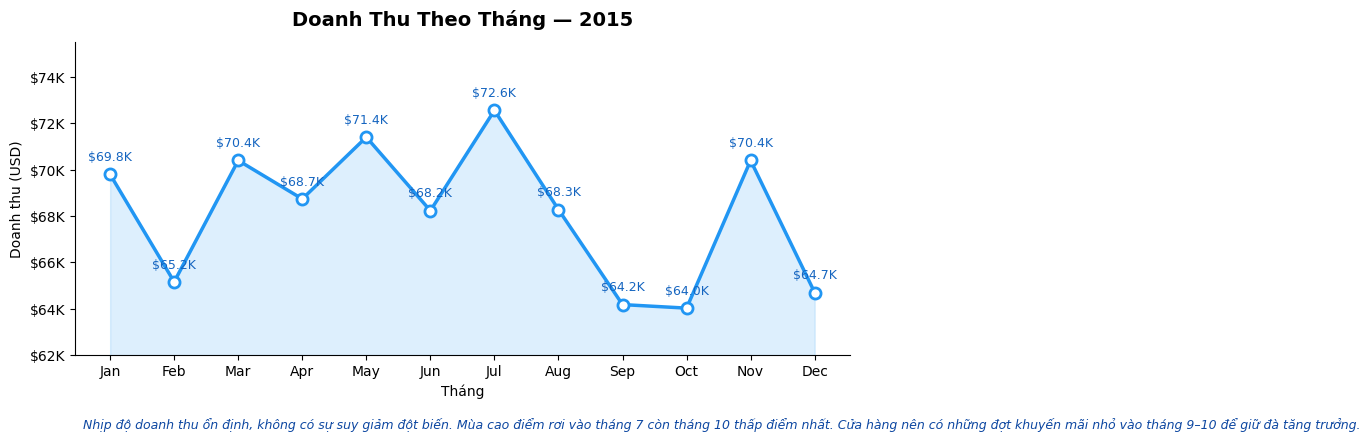

In [ ]:
# Doanh thu theo tháng (Line Chart)

monthly = df.groupby("month")["revenue"].sum().reset_index()
monthly["month_label"] = pd.to_datetime(monthly["month"], format="%m").dt.strftime("%b")

fig, (ax, ax_i) = plt.subplots(2, 1, figsize=(10, 5),
                                gridspec_kw={"height_ratios": [5, 1], "hspace": 0.05})

ax.plot(monthly["month"], monthly["revenue"], marker="o", linewidth=2.5,
        color="#2196F3", markerfacecolor="white", markeredgewidth=2, markersize=8)
ax.fill_between(monthly["month"], monthly["revenue"], y2=62000, alpha=0.15, color="#2196F3")

for _, row in monthly.iterrows():
    ax.annotate(f'${row["revenue"]/1e3:.1f}K',
                xy=(row["month"], row["revenue"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#1565C0")

ax.set_xticks(monthly["month"])
ax.set_xticklabels(monthly["month_label"])
ax.set_ylim(62000, 75500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_title("Doanh Thu Theo Tháng — 2015", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Tháng"); ax.set_ylabel("Doanh thu (USD)")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# Insight box
ax_i.set_facecolor("#E3F2FD"); ax_i.axis("off")
ax_i.text(0.01, 0.05,
          "Nhịp độ doanh thu ổn định, không có sự suy giảm đột biến. "
          "Mùa cao điểm rơi vào tháng 7 còn tháng 10 thấp điểm nhất. "
          "Cửa hàng nên có những đợt khuyến mãi nhỏ vào tháng 9–10 để giữ đà tăng trưởng.",
          va="center", fontsize=9, color="#0D47A1", fontstyle="italic",
          transform=ax_i.transAxes)

plt.tight_layout()
plt.show()

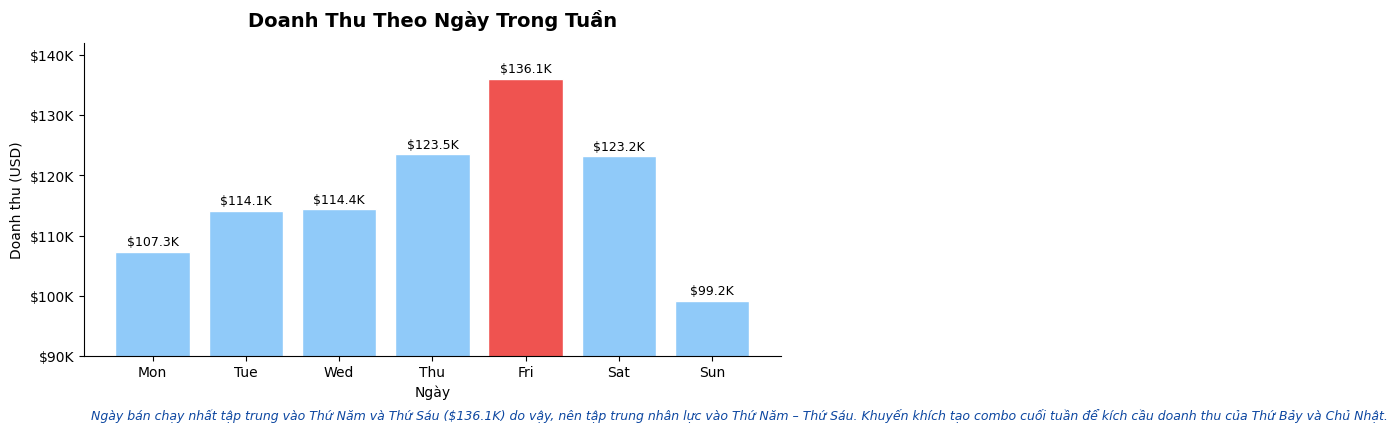

In [ ]:
# Doanh thu theo ngày trong tuần (Bar Chart)

df["dayofweek"] = df["date"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("dayofweek")["revenue"].sum().reindex(day_order).reset_index()
dow.columns = ["day","revenue"]
colors = ["#EF5350" if d == dow.loc[dow["revenue"].idxmax(),"day"] else "#90CAF9"
          for d in dow["day"]]

fig, (ax, ax_i) = plt.subplots(2, 1, figsize=(9, 5),
                                gridspec_kw={"height_ratios": [5, 1], "hspace": 0.05})

bars = ax.bar(dow["day"], dow["revenue"], color=colors, edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${bar.get_height()/1e3:.1f}K', ha="center", va="bottom", fontsize=9)

ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
ax.set_ylim(90000, 142000)                          # zoom vào vùng dữ liệu
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_title("Doanh Thu Theo Ngày Trong Tuần", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Ngày"); ax.set_ylabel("Doanh thu (USD)")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# Insight box
ax_i.set_facecolor("#E3F2FD"); ax_i.axis("off")
ax_i.text(0.01, 0.2,
          "Ngày bán chạy nhất tập trung vào Thứ Năm và Thứ Sáu ($136.1K) do vậy, nên tập trung nhân lực vào Thứ Năm – Thứ Sáu."
          " Khuyến khích tạo combo cuối tuần để kích cầu doanh thu của Thứ Bảy và Chủ Nhật.",
          va="center", fontsize=9, color="#0D47A1", fontstyle="italic",
          transform=ax_i.transAxes)

plt.tight_layout()
plt.show()


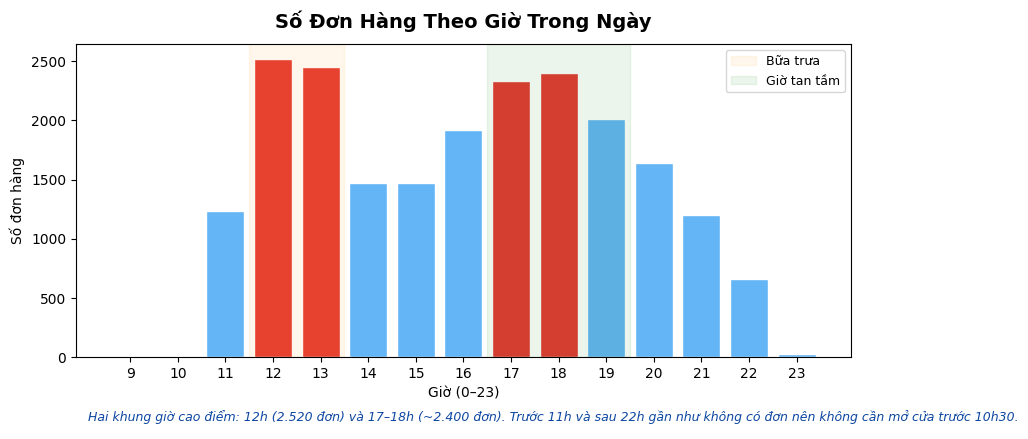

In [ ]:
# Số đơn hàng theo giờ trong ngày (Bar Chart)

hourly = df.groupby("hour")["order_id"].nunique().reset_index()
hourly.columns = ["hour","orders"]

fig, (ax, ax_i) = plt.subplots(2, 1, figsize=(10, 5),
                                gridspec_kw={"height_ratios": [5, 1], "hspace": 0.05})

ax.bar(hourly["hour"], hourly["orders"],
       color=["#E53935" if h in [12,13,17,18] else "#64B5F6" for h in hourly["hour"]],
       edgecolor="white")
ax.axvspan(11.5, 13.5, alpha=0.08, color="orange", label="Bữa trưa")
ax.axvspan(16.5, 19.5, alpha=0.08, color="green",  label="Giờ tan tầm")
ax.set_xticks(hourly["hour"])
ax.set_title("Số Đơn Hàng Theo Giờ Trong Ngày", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Giờ (0–23)"); ax.set_ylabel("Số đơn hàng")
ax.legend(fontsize=9)

# Insight box
ax_i.set_facecolor("#E3F2FD"); ax_i.axis("off")
ax_i.text(0.01, 0.2,
          " Hai khung giờ cao điểm: 12h (2.520 đơn) và 17–18h (~2.400 đơn). "
          "Trước 11h và sau 22h gần như không có đơn nên không cần mở cửa trước 10h30.",
          va="center", fontsize=9, color="#0D47A1", fontstyle="italic",
          transform=ax_i.transAxes)

plt.tight_layout()
plt.show()

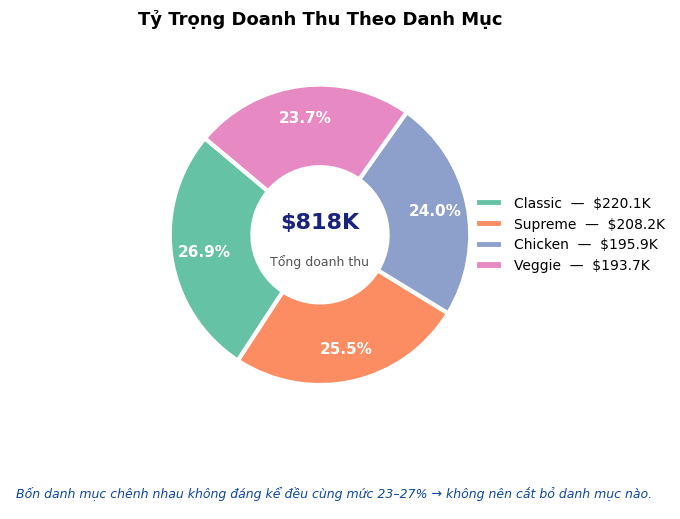

In [ ]:
# Doanh thu theo danh mục pizza (Donut Chart)

import seaborn as sns

cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[5, 1], hspace=0.05)
ax   = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])

colors = sns.color_palette("Set2", len(cat_rev))
wedges, texts, autotexts = ax.pie(
    cat_rev,
    labels=None,                                        # bỏ label mặc định, dùng legend
    autopct="%1.1f%%",
    colors=colors,
    wedgeprops={"edgecolor":"white", "linewidth":3, "width":0.55},
    startangle=140,
    pctdistance=0.78)

for at in autotexts:
    at.set_fontsize(11); at.set_fontweight("bold"); at.set_color("white")

# Nhãn giữa
ax.text(0, 0.08, f"${cat_rev.sum()/1e3:.0f}K",
        ha="center", va="center", fontsize=16, fontweight="bold", color="#1A237E")
ax.text(0, -0.18, "Tổng doanh thu",
        ha="center", va="center", fontsize=9, color="#555")

# Legend bên phải
ax.legend(wedges,
          [f"{cat}  —  ${v/1e3:.1f}K" for cat, v in zip(cat_rev.index, cat_rev.values)],
          loc="center left", bbox_to_anchor=(0.88, 0.5),
          fontsize=10, frameon=False)

ax.set_title("Tỷ Trọng Doanh Thu Theo Danh Mục", fontsize=13, fontweight="bold", pad=16)

# Insight box
ax_i.set_facecolor("#E3F2FD"); ax_i.axis("off")
ax_i.text(0.01, 0.2,
          "Bốn danh mục chênh nhau không đáng kể đều cùng mức 23–27% → không nên cắt bỏ danh mục nào. ",
          va="center", fontsize=9, color="#0D47A1", fontstyle="italic",
          transform=ax_i.transAxes)

plt.tight_layout()
plt.show()

In [ ]:
#  Storytelling — Một Năm Bán Pizza: Câu Chuyện Đằng Sau Những Con Số
# > *Nhìn vào 4 biểu đồ, ta không chỉ thấy doanh thu — ta thấy nhịp sống của cửa hàng: lúc nào đông, lúc nào vắng, khách thích gì, và cơ hội nào đang bị bỏ ngỏ.*

# Biểu đồ 1 — Doanh Thu Theo Tháng (2015)
#
# Nhìn vào đường line xuyên suốt 12 tháng, điều đầu tiên ta nhận ra là cửa hàng này **không có tháng nào thực sự giảm sâu** — biên độ dao động chỉ từ \$64K đến \$72.6K. Đây là tín hiệu tốt: nền khách hàng ổn định, không phụ thuộc vào một mùa duy nhất.
#
# Tuy nhiên, đường zigzag lên–xuống xuyên năm lại tiết lộ điều thú vị hơn. Tháng 7 đạt đỉnh với**\$72.6K** — mùa hè, học sinh nghỉ, nên có nhiều bữa tiệc, liên hoan hơn. Tuy vậy, doanh thu có phần giảm nhiều vào tháng 9–10 (**\$64K**) khi mọi người quay lại guồng học và làm việc. Tháng 11 bật trở lại \$70.4K nhờ mùa lễ hội, rồi lại hạ nhiệt vào tháng 12 khi nhiều khách chọn bữa ăn gia đình thay vì gọi đồ ăn ngoài.
#
# Hướng kinh doanh: Tháng 9–10 là "vùng trũng" cần can thiệp — hãy tạo các combo khuyến mãi *"Back to School"* hoặc deal nhóm nhỏ cho dân văn phòng có thể kéo doanh thu lên thêm 5–8% mà không cần tăng chi phí cố định.

# Biểu đồ 2 — Doanh Thu Theo Ngày Trong Tuần
#
# Cột đỏ của Thứ Sáu cao vút — **\$136.1K**, gần gấp rưỡi so với Chủ Nhật (\$99.2K). Điều này không bất ngờ: Thứ Sáu là ngày nghỉ ngơi sau 1 tuần dài, người ta ít nấu ăn nhất trong tuần và sẵn sàng chi tiền cho bữa tối ngon.
#
# Điều đáng chú ý hơn là Thứ Năm và Thứ Bảy gần ngang nhau (~\$123K), tạo thành **cụm cuối tuần** từ Thứ Năm đến Thứ Bảy. Trong khi đó, đầu tuần (Thứ Hai: \$107.3K, Chủ Nhật: \$99.2K) lại giảm đáng kể.
#
# Hướng kinh doanh:** Bố trí nhân lực và nguyên liệu tập trung vào Thứ Năm–Thứ Sáu–Thứ Bảy. Riêng Chủ Nhật và Thứ Hai, cân nhắc chạy chương trình *"Family Sunday"* hoặc deal combo để kéo thêm doanh thu vào ngày yếu nhất tuần.

# Biểu đồ 3 — Số Đơn Hàng Theo Giờ Trong Ngày
#
# Biểu đồ này là bức chân dung rõ nét nhất về hành vi khách hàng. Cửa hàng có **hai đỉnh tách biệt hoàn toàn**: giờ trưa 12–13h (~2.500 đơn) và giờ tan tầm 17–18h (~2.400 đơn). Hai làn sóng này gần như đối xứng, cho thấy tệp khách chủ yếu là dân văn phòng và học sinh — ăn trưa nhanh rồi lại gọi bữa tối sau giờ làm.
#
# Khoảng 14–16h — "giờ chết" — đơn hàng giảm còn khoảng 1.500, bằng 60% đỉnh trưa. Trước 11h và sau 22h gần như không có đơn. **Điều này có nghĩa là cửa hàng không cần mở cửa trước 10h30**, tiết kiệm chi phí vận hành buổi sáng sớm mà không mất doanh thu.
#
# Hướng kinh doanh:** Tăng ca bếp vào 11h–13h và 16h–19h; giảm nhân lực khung 14–16h. Cân nhắc *"Happy Hour"* 14–16h với giá ưu đãi để san phẳng nhu cầu, giúp bếp hoạt động đều hơn và giảm áp lực giờ cao điểm.

# Biểu đồ 4 — Tỉ Trọng Doanh Thu Theo Danh Mục
#
# Biểu đồ donut tiết lộ một thực tế hiếm gặp trong kinh doanh F&B: **cả 4 danh mục đều cân bằng** — Classic (26.9%), Supreme (25.5%), Chicken (24.0%), Veggie (23.7%). Tổng doanh thu cả năm đạt **\$818K**.
#
# Điều này vừa là điểm mạnh vừa là thách thức. Điểm mạnh: cửa hàng không phụ thuộc vào một loại pizza duy nhất, rủi ro phân tán tốt. Thách thức: không có điểm nhấn rõ ràng để đẩy marketing — mọi thứ đều tầm tầm như nhau. Classic dẫn đầu nhưng chỉ hơn Veggie **3.2 điểm phần trăm** — hoàn toàn không có khoảng cách để tự tin cắt bỏ danh mục nào.
#
# Hướng kinh doanh:** Thay vì cắt danh mục, hãy xây dựng *"hero product"* trong từng nhóm — chọn 1–2 pizza đại diện để đẩy mạnh truyền thông. Đồng thời theo dõi xem Veggie có tăng trưởng không, vì xu hướng ăn chay/thuần thực vật ngày càng mạnh.

# Kết Luận — Bức Tranh Tổng Thể
#
# | Chỉ số | Giá trị |
# |---|---|
# | Tổng doanh thu 2015 | **\$818,000** |
# | Tháng cao điểm | **Tháng 7** (\$72.6K) |
# | Tháng thấp điểm | **Tháng 10** (\$64.0K) |
# | Ngày bán chạy nhất | **Thứ Sáu** (\$136.1K) |
# | Ngày bán chậm nhất | **Chủ Nhật** (\$99.2K) |
# | Hai giờ vàng | **12h và 17–18h** |
# | Danh mục dẫn đầu | **Classic** (26.9%) |
#
# Đây là cửa hàng pizza có nền tảng vững — doanh thu ổn định, danh mục cân bằng, và khách hàng có thói quen mua lặp lại rõ ràng.
#
# **Ba đòn bẩy lớn nhất còn chưa tận dụng hết:**
# 1. **Kích hoạt tháng 9–10** thay vì để trống bằng các chương trình khuyến mãi có chủ đề
# 2. **Tận dụng "giờ chết" 14–16h** bằng Happy Hour để san phẳng tải bếp
# 3. **Xây ngôi sao đại diện** cho từng danh mục pizza để có câu chuyện marketing rõ ràng hơn